In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Hiperparámetros
lr = 1 # Tasa de aprendizaje

In [ ]:
# Funciones Auxiliares

# Sigmoide - Etapa 3
def sigmoid(x):
    x = np.asarray(x)
    return 1 / (1 + np.exp(-x))

# Derivada Sigmoide - Etapa 5
def sigmoid_derivative(x):
    x = np.asarray(x)
    s = sigmoid(x)
    return s * (1 - s)

# Error Cuadrático Medio - Etapa 4
def loss(y_real, y_pred):
  return np.mean((y_real - y_pred) ** 2)

# Derivada Error Cuadrático Medio (Respecto a y_pred) - Etapa 5
def loss_derivative(y_real, y_pred):
    # dL/dy_pred = (-2/m) * (y_real - y_pred)
    m = y_real.shape[0]
    return (-2/m) * (y_real - y_pred)


# No lo uso
"""
def relu(x):
    # Ensure x is a numpy array and use np.maximum for element-wise operation
    x = np.asarray(x)
    return np.maximum(0, x)

x_test = [-2,-1,0,1,2] # Renamed variable to avoid conflict and make it clear it's test data
print(f"Input: {x_test}")
print(f"Sigmoid output: {sigmoid(x_test)}")
print(f"Sigmoid derivative output: {sigmoid_derivative(x_test)}")
print(f"ReLU output: {relu(x_test)}")
"""

'\ndef relu(x):\n    # Ensure x is a numpy array and use np.maximum for element-wise operation\n    x = np.asarray(x)\n    return np.maximum(0, x)\n\nx_test = [-2,-1,0,1,2] # Renamed variable to avoid conflict and make it clear it\'s test data\nprint(f"Input: {x_test}")\nprint(f"Sigmoid output: {sigmoid(x_test)}")\nprint(f"Sigmoid derivative output: {sigmoid_derivative(x_test)}")\nprint(f"ReLU output: {relu(x_test)}")\n'

In [ ]:
"""
MODELO: Predictor de XOR
Entrada (2 números)
↓
Capa oculta
(3 neuronas)
↓
Salida
(1 neurona)
"""
# Etapa 1 - Datasets ===============================================================================================================
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]) # Entradas del dataset (cada fila es un ejemplo)
y = np.array([[0], [1], [1], [0]]) # dataset de datos de salida

# Etapa 2 - Inicializar Pesos ======================================================================================================
## Primera capa - (2 números a 3 neuronas)
W1 = np.random.randn(2,3) # Pesos que conectan las entradas con la capa oculta
b1 = np.random.randn(1,3) # Bias de cada neurona de la capa oculta (Sesgo)

## Segunda capa - (3 neuronas a 1 neurona)
W2 = np.random.randn(3,1) # Pesos que conectan la capa oculta con la salida
b2 = np.random.randn(1,1) # Bias de la neurona de salida

# Etapa 7 - Entrenamiento ==========================================================================================================
losses = [] # Historial de pérdidas durante el entrenamiento.
for epoch in range(10000):
  # Etapa 3 - Forward ==============================================================================================================
  Z1 = X@W1 + b1  # Suma ponderada de cada neurona antes de aplicar la activación. Cada fila = un ejemplo del dataset. Cada columna = una neurona de esa capa.
  A1 = sigmoid(Z1) # Activación (salida) de las neuronas de la capa oculta

  Z2 = A1@W2 + b2 # Suma ponderada de la neurona de salida antes de la activación
  A2 = sigmoid(Z2) # Predicción de la red para cada ejemplo del dataset.

  # Etapa 4 - Función de Pérdida ===================================================================================================
  costo = loss(y, A2) # Valor actual de la función de pérdida.
  losses.append(costo) # Guarda la pérdida de esta época para visualizar cómo aprende la red.

  # Etapa 5 - Backpropagation ======================================================================================================
  ## Gradiente de la función de pérdida con respecto a la activación de salida (A2)
  dL_dA2 = loss_derivative(y, A2)
  ## Gradiente de la función de pérdida con respecto a la entrada pre-activación de la capa de salida (Z2)
  ## dL/dZ2 = dL/dA2 * dA2/dZ2
  dL_dZ2 = dL_dA2 * sigmoid_derivative(Z2)

  ## Gradiente de la función de pérdida con respecto a los pesos de la capa de salida (W2)
  ## dL/dW2 = A1.T @ dL/dZ2
  dL_dW2 = A1.T @ dL_dZ2
  ## Gradiente de la función de pérdida con respecto al bias de la capa de salida (b2)
  ## dL/db2 = sum(dL/dZ2)
  dL_db2 = np.sum(dL_dZ2, axis=0, keepdims=True) # Suma los gradientes de todos los ejemplos del batch para obtener el gradiente del bias de salida.

  ## Gradiente de la función de pérdida con respecto a la activación de la capa oculta (A1)
  ## dL/dA1 = dL/dZ2 @ dZ2/dA1
  ## Donde dZ2/dA1 es W2 transpuesta
  dL_dA1 = dL_dZ2 @ W2.T

  ## Gradiente de la función de pérdida con respecto a la entrada pre-activación de la capa oculta (Z1)
  ## dL/dZ1 = dL/dA1 * dA1/dZ1
  dL_dZ1 = dL_dA1 * sigmoid_derivative(Z1)

  ## Gradiente de la función de pérdida con respecto a los pesos de la capa oculta (W1)
  ## dL/dW1 = X.T @ dL/dZ1
  dL_dW1 = X.T @ dL_dZ1
  ## Gradiente de la función de pérdida con respecto al bias de la capa oculta (b1)
  ## dL/db1 = sum(dL/dZ1)
  dL_db1 = np.sum(dL_dZ1, axis=0, keepdims=True) # Suma los gradientes de todos los ejemplos del batch para obtener el gradiente del bias de salida.

  # Etapa 6 - Actualizar Pesos =====================================================================================================
  W1 = W1 - lr * dL_dW1 # Descenso por gradiente sobre los pesos de la capa oculta.
  b1 = b1 - lr * dL_db1 # Actualiza los bias de la capa oculta utilizando el gradiente calculado.
  W2 = W2 - lr * dL_dW2 # Descenso por gradiente sobre los pesos de la capa de salida.
  b2 = b2 - lr * dL_db2 # Actualiza el bias de la neurona de salida.

  # if epoch % 500 == 0:
  #  print(f"Época {epoch}:\nPredicciones A2:\n{A2}")

print(f"Predicción final: \n{A2}")

Predicción final: 
[[0.01829093]
 [0.98429594]
 [0.98423721]
 [0.01615361]]


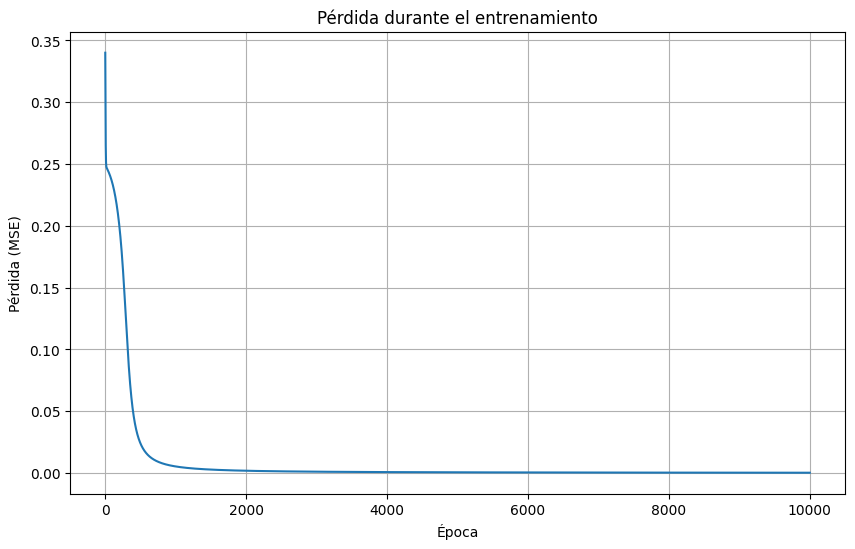

In [ ]:
# Etapa 8 - Graficar la Pérdida
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.grid(True)
plt.show()

# Versión Limpia

Predicción final: 
[[0.01714263]
 [0.98072663]
 [0.9838391 ]
 [0.0151297 ]]


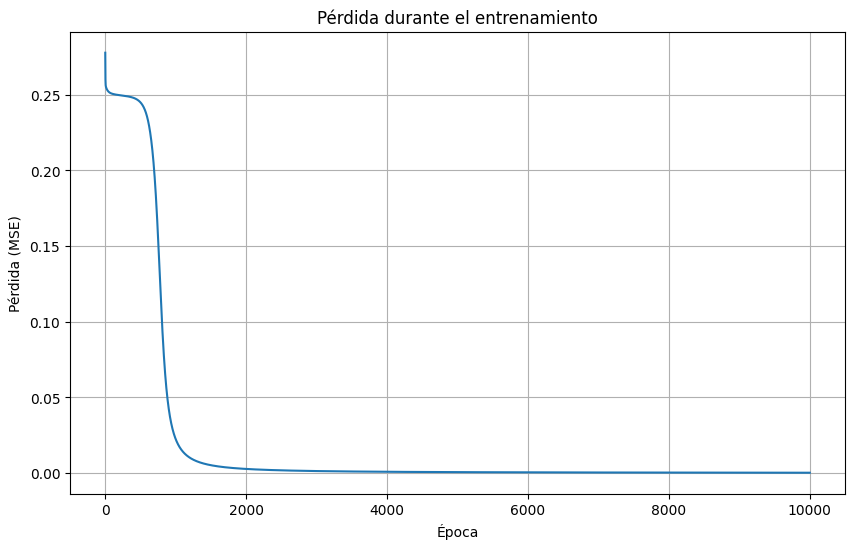

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Hiperparámetros
lr = 1

# Funciones Auxiliares
def sigmoid(x):
    x = np.asarray(x)
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    x = np.asarray(x)
    s = sigmoid(x)
    return s * (1 - s)

def loss(y_real, y_pred):
  return np.mean((y_real - y_pred) ** 2)

def loss_derivative(y_real, y_pred):
    m = y_real.shape[0]
    return (-2/m) * (y_real - y_pred)


# Datasets
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Inicializar Pesos
## Primera capa
W1 = np.random.randn(2,3)
b1 = np.random.randn(1,3)
## Segunda capa
W2 = np.random.randn(3,1)
b2 = np.random.randn(1,1)

# Entrenamiento
losses = []
for epoch in range(10000):
  # Forward
  Z1 = X@W1 + b1
  A1 = sigmoid(Z1)
  Z2 = A1@W2 + b2
  A2 = sigmoid(Z2)

  # Función de Pérdida
  costo = loss(y, A2)
  losses.append(costo)

  # Backpropagation
  dL_dA2 = loss_derivative(y, A2)
  dL_dZ2 = dL_dA2 * sigmoid_derivative(Z2)
  dL_dW2 = A1.T @ dL_dZ2
  dL_db2 = np.sum(dL_dZ2, axis=0, keepdims=True)
  dL_dA1 = dL_dZ2 @ W2.T
  dL_dZ1 = dL_dA1 * sigmoid_derivative(Z1)
  dL_dW1 = X.T @ dL_dZ1
  dL_db1 = np.sum(dL_dZ1, axis=0, keepdims=True)

  # Actualizar Pesos
  W1 = W1 - lr * dL_dW1
  b1 = b1 - lr * dL_db1
  W2 = W2 - lr * dL_dW2
  b2 = b2 - lr * dL_db2

print(f"Predicción final: \n{A2}")

# Graficar la Pérdida
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.grid(True)
plt.show()